# Application on NSCLC-SCLC transition

In [1]:
from pathlib import Path
import json
import anndata as ad
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
import gseapy as gp
from adjustText import adjust_text

import scdebussy
from scdebussy.tl import (
    cluster_and_order_genes,
    compute_composite_alignment_score,
    compute_gene_trend_features,
    compute_trend_recurrence_score,
    cosegment_ordered_heatmap,
    filter_informative_genes,
    filter_recurrent_hvgs,
    load_from_manifest,
    compute_running_enrichment,
    temporal_kernel_pseudotime_enrichment,
    remove_cell_cycle_genes,
)
from scdebussy.pl import plot_running_enrichment_ridge

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [2]:
# Configure paths and analysis keys
REPO_ROOT = Path("/data1/chanj3/wangm10/scDeBussy")
RESULTS_ROOT = Path("/scratch/chanj3/wangm10/HTAN/results")

# Option A: load an already aligned AnnData (recommended for figure regeneration)
ALIGNED_ADATA_PATH = None  # Example: Path('/scratch/.../aligned_scdebussy.h5ad')

# Option B: load staged per-patient h5ad files and run scDeBussy in-notebook
STAGED_MANIFEST = Path("/scratch/chanj3/wangm10/HTAN/preprocessed/staged_paths.txt")

PATIENT_KEY = "patient"
PSEUDOTIME_KEY = "s_local"
ALIGNED_KEY = "aligned_pseudotime"
CELL_TYPE_KEY = "cell_type_final2"
BARYCENTER_KEY = "barycenter"

# Filter out non-informative genes before recurrent HVG filtering
USE_INFORMATIVE_GENE_FILTER = True
GENE_ANNOTATION_SPECIES = "hsapiens_gene_ensembl"
GENE_ANNOTATION_HOST = "http://www.ensembl.org"

# Recurrent HVG filter applied before scDeBussy when starting from staged per-patient files
USE_RECURRENT_HVG_FILTER = True
HVG_TOP_PER_PATIENT = 3000
HVG_MIN_PATIENTS = None  # Defaults to max(2, ceil(n_patients / 2))
HVG_MATRIX_LAYER = "counts"  # Falls back to X if missing

# Figure output folder
FIG_DIR = RESULTS_ROOT / "figures" / "HTAN_demo"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"Figure output directory: {FIG_DIR}")

Figure output directory: /scratch/chanj3/wangm10/HTAN/results/figures/HTAN_demo


In [3]:
if ALIGNED_ADATA_PATH is not None and Path(ALIGNED_ADATA_PATH).exists():
    adata = ad.read_h5ad(ALIGNED_ADATA_PATH)
    recurrent_hvg_counts = None
    print(f"Loaded aligned AnnData: {ALIGNED_ADATA_PATH}")
    if USE_INFORMATIVE_GENE_FILTER or USE_RECURRENT_HVG_FILTER:
        print("Note: gene filtering is skipped when loading a pre-aligned AnnData.")
else:
    adata = load_from_manifest(STAGED_MANIFEST)
    recurrent_hvg_counts = None
    print(f"Loaded staged and concatenated AnnData from: {STAGED_MANIFEST}")

    if USE_INFORMATIVE_GENE_FILTER:
        adata = filter_informative_genes(
            adata,
            species=GENE_ANNOTATION_SPECIES,
            host=GENE_ANNOTATION_HOST,
        )
        print("Applied informative-gene filter:", adata.uns["informative_gene_filter"])

    if USE_RECURRENT_HVG_FILTER:
        adata, recurrent_hvg_counts = filter_recurrent_hvgs(
            adata,
            patient_key=PATIENT_KEY,
            top_per_patient=HVG_TOP_PER_PATIENT,
            min_patients=HVG_MIN_PATIENTS,
            layer_name=HVG_MATRIX_LAYER,
        )
        print("Applied recurrent HVG filter:", adata.uns["recurrent_hvg_filter"])

missing_obs = [k for k in [PATIENT_KEY, PSEUDOTIME_KEY, CELL_TYPE_KEY] if k not in adata.obs.columns]
if missing_obs:
    raise ValueError(f"Missing required adata.obs keys: {missing_obs}")

# If alignment/barycenter are missing, run scDeBussy once in notebook.
if ALIGNED_KEY not in adata.obs.columns or BARYCENTER_KEY not in adata.uns:
    print("Running scDeBussy to compute aligned pseudotime and barycenter...")
    scdebussy.tl.scDeBussy(
        adata,
        patient_key=PATIENT_KEY,
        pseudotime_key=PSEUDOTIME_KEY,
        key_added=ALIGNED_KEY,
        barycenter_key=BARYCENTER_KEY,
        verbose=False,
    )

print("adata shape:", adata.shape)
print("aligned key present:", ALIGNED_KEY in adata.obs.columns)
print("barycenter key present:", BARYCENTER_KEY in adata.uns)
if "informative_gene_filter" in adata.uns:
    print("informative_gene_filter:", adata.uns["informative_gene_filter"])
if "recurrent_hvg_filter" in adata.uns:
    print("recurrent_hvg_filter:", adata.uns["recurrent_hvg_filter"])

Loaded staged and concatenated AnnData from: /scratch/chanj3/wangm10/HTAN/preprocessed/staged_paths.txt
Applied informative-gene filter: {'annotation_source': 'ensembl_protein_coding_plus_regex', 'species': 'hsapiens_gene_ensembl', 'host': 'http://www.ensembl.org', 'n_genes_before': 26660, 'n_genes_after': 17472}
Applied recurrent HVG filter: {'top_per_patient': 3000, 'min_patients': 5, 'n_patients': 9, 'n_genes_selected': 2365, 'source_layer': 'counts'}
Running scDeBussy to compute aligned pseudotime and barycenter...
adata shape: (36379, 2365)
aligned key present: True
barycenter key present: True
informative_gene_filter: {'annotation_source': 'ensembl_protein_coding_plus_regex', 'species': 'hsapiens_gene_ensembl', 'host': 'http://www.ensembl.org', 'n_genes_before': 26660, 'n_genes_after': 17472}
recurrent_hvg_filter: {'top_per_patient': 3000, 'min_patients': 5, 'n_patients': 9, 'n_genes_selected': 2365, 'source_layer': 'counts'}


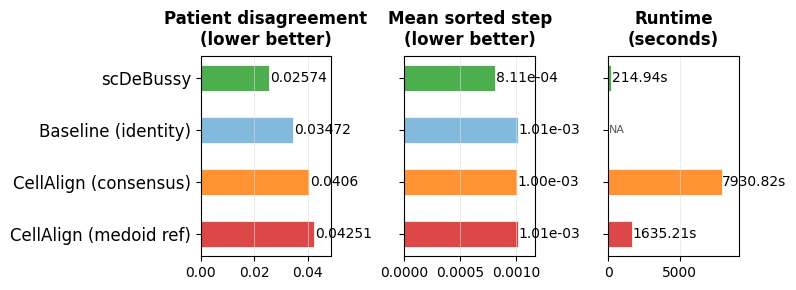

Saved: /scratch/chanj3/wangm10/HTAN/results/figures/HTAN_demo/method_comparison_combined_2x2.png


In [5]:
comparison_methods = [
    ("identity", "Baseline (identity)"),
    ("scdebussy", "scDeBussy"),
    ("cellalign_fixed_reference", "CellAlign (medoid ref)"),
    ("cellalign_consensus", "CellAlign (consensus)"),
]
method_colors = {
    "identity": "#6baed6",
    "scdebussy": "#2ca02c",
    "cellalign_fixed_reference": "#d62728",
    "cellalign_consensus": "#ff7f0e",
}
run_rows = []
missing_methods = []

for method_key, method_label in comparison_methods:
    method_dir = RESULTS_ROOT / method_key / "real_data"
    seed_files = sorted(method_dir.glob("seed_*.json"))
    if not seed_files:
        missing_methods.append(str(method_dir))
        continue

    for seed_file in seed_files:
        payload = json.loads(seed_file.read_text(encoding="utf-8"))
        unsup = payload.get("unsupervised", {})
        seed_name = seed_file.stem
        seed_id = int(seed_name.replace("seed_", ""))

        run_rows.append(
            {
                "method_key": method_key,
                "method": method_label,
                "seed": seed_id,
                "runtime_s": float(payload.get("runtime_s", np.nan)),
                "unsupervised_score_generic": float(unsup.get("unsupervised_score_generic", np.nan)),
                "patient_hist_disagreement": float(unsup.get("patient_hist_disagreement", np.nan)),
                "mean_sorted_step": float(unsup.get("mean_sorted_step", np.nan)),
            }
        )

if missing_methods:
    print("No seed_*.json files found under:")
    for p in missing_methods:
        print(" -", p)

run_df = pd.DataFrame(run_rows)
if run_df.empty:
    raise RuntimeError("No method summaries were found under RESULTS_ROOT.")

summary = (
    run_df.groupby(["method_key", "method"], as_index=False)[
        ["unsupervised_score_generic", "patient_hist_disagreement", "mean_sorted_step", "runtime_s"]
    ]
    .mean()
    .reset_index(drop=True)
)

# Runtime fairness: identity does not run an algorithm, so mark runtime as NA.
summary["runtime_s_plot"] = summary["runtime_s"]
summary.loc[summary["method_key"] == "identity", "runtime_s_plot"] = np.nan

# Order methods by quality-only performance (best to worst), excluding runtime.

quality_cols = ["unsupervised_score_generic", "patient_hist_disagreement", "mean_sorted_step"]
perf = summary.set_index("method_key")[quality_cols].copy()
z_perf = perf.copy()

for c in quality_cols:
    col = perf[c]
    sd = col.std(ddof=0)
    denom = sd if np.isfinite(sd) and sd > 1e-12 else 1.0
    z_perf[c] = (col - col.mean()) / denom

perf["overall_quality"] = -z_perf.mean(axis=1)  # lower metric values are better
method_order = perf.sort_values("overall_quality", ascending=False).index.tolist()
method_label_map = dict(comparison_methods)
summary["method_order"] = summary["method_key"].map({k: i for i, k in enumerate(method_order)})
summary = summary.sort_values("method_order").drop(columns="method_order").reset_index(drop=True)


# Plot 1: quality metrics on original scales, split into subplots for fairness of scale.
# Combined panel: quality metrics and runtime (horizontal bars; best methods on top)
all_specs = [
    ("patient_hist_disagreement", "Patient disagreement\n(lower better)"),
    ("mean_sorted_step", "Mean sorted step\n(lower better)"),
    ("runtime_s_plot", "Runtime\n(seconds)"),
]

fig, axes = plt.subplots(1, 3, figsize=(8, 3), sharey=True)
axes = axes.flatten()
y = np.arange(len(method_order))
method_labels = [method_label_map[k] for k in method_order]

for ax, (metric_key, metric_title) in zip(axes, all_specs, strict=True):
    vals = []
    for method_key in method_order:
        v = summary.loc[summary["method_key"] == method_key, metric_key].iloc[0]
        vals.append(np.nan if not np.isfinite(v) else float(v))

    bars = ax.barh(
        y,
        np.nan_to_num(vals, nan=0.0),
        color=[method_colors.get(k, "#888888") for k in method_order],
        alpha=0.85,
        edgecolor="white",
        linewidth=0.6,
        height=0.5,
    )

    ax.set_title(metric_title, fontsize=12, fontweight="bold", pad=8)
    ax.set_yticks(y)
    ax.set_yticklabels(method_labels, fontsize=12)
    ax.invert_yaxis()  # Best methods (ordered first) appear at the top.
    ax.grid(axis="x", linewidth=0.4, color="0.88", zorder=0)

    finite_vals = [v for v in vals if np.isfinite(v)]
    xmax = max(finite_vals) if finite_vals else 1.0
    pad = xmax * 0.15 if xmax > 0 else 0.1
    ax.set_xlim(0, xmax + pad)

    # Bar annotations
    for b, v in zip(bars, vals, strict=True):
        y_center = b.get_y() + b.get_height() / 2
        if np.isfinite(v):
            if metric_key == "runtime_s_plot":
                text_val = f"{v:.2f}s"
            elif metric_key == "mean_sorted_step":
                text_val = f"{v:.2e}" if abs(v) < 1e-2 else f"{v:.3f}"
            else:
                text_val = f"{v:.4g}"
            ax.text(
                v + 0.03 * pad,
                y_center,
                text_val,
                ha="left",
                va="center",
                fontsize=10,
            )
        else:
            ax.text(
                0.03 * pad,
                y_center,
                "NA",
                ha="left",
                va="center",
                fontsize=8,
                color="0.35",
            )

fig.tight_layout()
f_combined = FIG_DIR / "method_comparison_combined_2x2.png"
fig.savefig(f_combined, dpi=220, bbox_inches="tight")
plt.show()
print(f"Saved: {f_combined}")

In [6]:
# Compute analysis objects from new trend-analysis APIs
if USE_INFORMATIVE_GENE_FILTER and "informative_gene_filter" not in adata.uns and ALIGNED_ADATA_PATH is None:
    raise ValueError("Expected informative_gene_filter metadata before running scDeBussy analysis.")
if USE_RECURRENT_HVG_FILTER and "recurrent_hvg_filter" not in adata.uns and ALIGNED_ADATA_PATH is None:
    raise ValueError("Expected recurrent_hvg_filter metadata before running scDeBussy analysis.")

safe_n_neighbors = min(50, max(2, int(adata.n_obs) - 1))
composite = compute_composite_alignment_score(
    adata,
    aligned_pseudotime_key=ALIGNED_KEY,
    label_key=CELL_TYPE_KEY,
    patient_key=PATIENT_KEY,
    n_neighbors=safe_n_neighbors,
    weight_global_purity=1.0,
    weight_class_stability=1.0,
    weight_recurrence=1.0,
)

trend_features = compute_gene_trend_features(adata, barycenter_key=BARYCENTER_KEY)
ordered_genes_df = cluster_and_order_genes(
    adata,
    barycenter_key=BARYCENTER_KEY,
    n_clusters=3,
    random_state=0,
    peak_weight=0.5,
)

recurrence = compute_trend_recurrence_score(
    adata,
    aligned_pseudotime_key=ALIGNED_KEY,
    patient_key=PATIENT_KEY,
)

/data1/chanj3/wangm10/scDeBussy/src/scdebussy/tl/_metrics.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  batch_counts = df.groupby(label_key)[batch_key].nunique()


In [7]:
# Figure 2: Ordered gene trend heatmap from barycenter expression with co-segmentation
bary_expr = np.asarray(adata.uns[BARYCENTER_KEY]["expression"], dtype=float)  # (n_bins, n_genes)
gene_index = {g: i for i, g in enumerate(adata.var_names.astype(str))}
ordered_gene_names = ordered_genes_df["gene"].tolist()
ordered_idx = [gene_index[g] for g in ordered_gene_names if g in gene_index]

heat = bary_expr[:, ordered_idx].T  # genes x bins
heat = (heat - heat.mean(axis=1, keepdims=True)) / (heat.std(axis=1, keepdims=True) + 1e-12)

genes_to_annotate = ["ASCL1", "NEUROD1", "TACSTD2", "CHGA", "EZH2", "DLL3"]
annot_positions = [(idx, gene) for idx, gene in enumerate(ordered_gene_names) if gene in genes_to_annotate]
missing_genes = [gene for gene in genes_to_annotate if gene not in ordered_gene_names]

# Infer per-bin label composition from aligned cells.
n_bins = bary_expr.shape[0]
aligned_values = adata.obs[ALIGNED_KEY].to_numpy(dtype=float)
cell_types = adata.obs[CELL_TYPE_KEY].astype(str).to_numpy()
valid = np.isfinite(aligned_values)
bin_idx = np.clip((aligned_values[valid] * (n_bins - 1)).astype(int), 0, n_bins - 1)
cell_types_valid = cell_types[valid]

phase_order = ["LUAD", "SCLC-A", "SCLC-N"]
phase_aliases = {
    "LUAD": "LUAD",
    "SCLC-A": "SCLC-A",
    "SCLC-N": "SCLC-N",
}
phase_counts = pd.DataFrame(0.0, index=np.arange(n_bins), columns=phase_order)
dominant_by_bin = []
for b in range(n_bins):
    labels_b = cell_types_valid[bin_idx == b]
    if len(labels_b) == 0:
        dominant_by_bin.append("Unassigned")
        continue
    counts_b = pd.Series(labels_b).value_counts()
    dominant_by_bin.append(str(counts_b.index[0]))
    total = float(counts_b.sum())
    for raw_label, count in counts_b.items():
        phase = phase_aliases.get(str(raw_label))
        if phase is not None:
            phase_counts.loc[b, phase] += float(count) / total

n_gene_clusters = max(1, min(3, int(ordered_genes_df["cluster_order"].nunique())))
n_phase_clusters = 3
cosegmentation = cosegment_ordered_heatmap(
    heat,
    n_row_clusters=n_gene_clusters,
    n_col_clusters=n_phase_clusters,
    min_rows_per_cluster=max(5, heat.shape[0] // 30),
    min_cols_per_cluster=max(3, n_bins // 12),
)
row_segments = cosegmentation["row_segments"]
col_segments = cosegmentation["col_segments"]

cluster_blocks = pd.DataFrame(
    [
        {
            "cluster_order": idx,
            "start_idx": start,
            "end_idx": end - 1,
        }
        for idx, (start, end) in enumerate(row_segments)
    ]
)
cluster_ids = np.empty(heat.shape[0], dtype=int)
for idx, (start, end) in enumerate(row_segments):
    cluster_ids[start:end] = idx

boundary_1 = col_segments[0][1]
boundary_2 = col_segments[1][1]

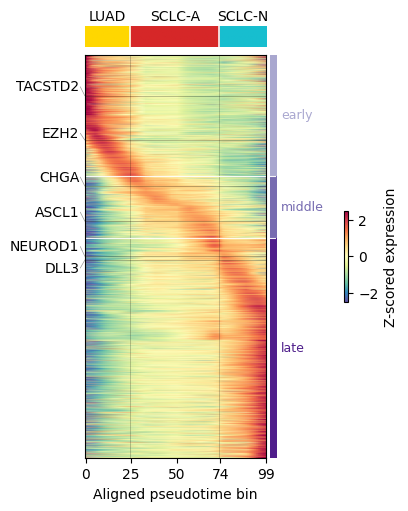

Saved: /scratch/chanj3/wangm10/HTAN/results/figures/HTAN_demo/figure2_ordered_gene_heatmap.png
Raw dominant cell-type segments: [(0, 0, 'LUAD'), (1, 7, 'SCLC-N'), (8, 14, 'SCLC-A'), (15, 16, 'LUAD'), (17, 22, 'SCLC-A'), (23, 23, 'LUAD'), (24, 24, 'SCLC-A'), (25, 25, 'LUAD'), (26, 26, 'SCLC-A'), (27, 27, 'LUAD'), (28, 52, 'SCLC-A'), (53, 54, 'SCLC-N'), (55, 58, 'SCLC-A'), (59, 60, 'SCLC-N'), (61, 63, 'SCLC-A'), (64, 64, 'SCLC-N'), (65, 65, 'SCLC-A'), (66, 99, 'SCLC-N')]
Co-segment column segments: [(0, 24, 'LUAD'), (25, 73, 'SCLC-A'), (74, 99, 'SCLC-N')]
Co-segment row segments: [{'cluster_order': 0, 'start_idx': 0, 'end_idx': 709}, {'cluster_order': 1, 'start_idx': 710, 'end_idx': 1075}, {'cluster_order': 2, 'start_idx': 1076, 'end_idx': 2364}]
Co-segmentation objective: 240423.5055102811
Co-segment block means: [[ 1.121 -0.249 -0.608]
 [-0.84   0.607 -0.336]
 [-1.021 -0.039  1.054]]


In [8]:
phase_colors = {
    "LUAD": "gold",
    "SCLC-A": "tab:red",
    "SCLC-N": "tab:cyan",
    "Segment 1": "#d9d9d9",
    "Segment 2": "#bdbdbd",
    "Segment 3": "#969696",
}

# Assign each bin a fixed segment label based on cosegmentation boundaries
phase_by_bin = np.where(
    np.arange(n_bins) < boundary_1,
    "LUAD",
    np.where(np.arange(n_bins) < boundary_2, "SCLC-A", "SCLC-N"),
)
phase_segments = [
    (0, boundary_1 - 1, "LUAD"),
    (boundary_1, boundary_2 - 1, "SCLC-A"),
    (boundary_2, n_bins - 1, "SCLC-N"),
]

annotation_rgb = np.array(
    [[plt.matplotlib.colors.to_rgba(phase_colors.get(phase, "#808080")) for phase in phase_by_bin]]
)
cluster_palette = plt.cm.Purples(np.linspace(0.45, 0.9, max(len(cluster_blocks), 2)))
cluster_cmap = ListedColormap(cluster_palette[: len(cluster_blocks)])
cluster_bar = cluster_ids[:, None]

fig = plt.figure(figsize=(4, 5), constrained_layout=True)
gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[0.05, 1.0], hspace=0.03)
ax_top = fig.add_subplot(gs[0])
ax = fig.add_subplot(gs[1], sharex=ax_top)

ax_top.imshow(annotation_rgb, aspect="auto")
ax_top.set_yticks([])
ax_top.tick_params(axis="x", bottom=False, top=False)
ax_top.tick_params(axis="x", labelbottom=False, labeltop=False)
ax_top.set_xlim(-0.5, n_bins - 0.5)
for left, right, label in phase_segments:
    center = (left + right) / 2
    ax_top.text(center, -0.65, label, ha="center", va="bottom", fontsize=10, clip_on=False)
for boundary in [boundary_1 - 0.5, boundary_2 - 0.5]:
    ax_top.axvline(boundary, color="white", linewidth=1.2, alpha=0.95)
for spine in ax_top.spines.values():
    spine.set_visible(False)

im = ax.imshow(heat, aspect="auto", cmap="Spectral_r", vmin=-2.5, vmax=2.5)
ax.set_xlabel("Aligned pseudotime bin")
ax.set_xticks(np.linspace(0, n_bins - 1, 5).round().astype(int))

if annot_positions:
    ax.set_yticks([])
    y_label_transform = plt.matplotlib.transforms.blended_transform_factory(ax.transAxes, ax.transData)
    x_label_anchor = -0.03
    gene_texts = []
    for pos, gene in annot_positions:
        ax.axhline(pos, color="black", linewidth=0.5, alpha=0.35)
        gene_texts.append(
            ax.text(
                x_label_anchor,
                pos,
                gene,
                transform=y_label_transform,
                ha="right",
                va="center",
                fontsize=10,
                clip_on=False,
            )
        )
    adjust_text(
        gene_texts,
        ax=ax,
        only_move={"points": "y", "text": "y"},
        autoalign="y",
        force_text=(0.12, 0.35),
        expand_text=(1.0, 1.2),
        ensure_inside_axes=False,
    )
    # Keep all labels on one vertical guide after y-only relaxation.
    for txt in gene_texts:
        txt.set_x(x_label_anchor)
        txt.set_ha("right")

    for (pos, _gene), txt in zip(annot_positions, gene_texts, strict=False):
        txt_y = txt.get_position()[1]
        ax.plot(
            [x_label_anchor + 0.005, 0.0],
            [txt_y, pos],
            transform=y_label_transform,
            color="black",
            lw=0.5,
            alpha=0.4,
            clip_on=False,
            solid_capstyle="round",
        )
else:
    ax.set_yticks([])

for boundary in [boundary_1 - 0.5, boundary_2 - 0.5]:
    ax.axvline(boundary, color="black", linewidth=0.7, alpha=0.22)

for _, block in cluster_blocks.iterrows():
    if block["start_idx"] > 0:
        ax.axhline(block["start_idx"] - 0.5, color="white", linewidth=0.8, alpha=0.9)

ax_cluster = ax.inset_axes([1.02, 0.0, 0.035, 1.0])
ax_cluster.imshow(
    cluster_bar,
    aspect="auto",
    cmap=cluster_cmap,
    vmin=-0.5,
    vmax=len(cluster_blocks) - 0.5,
    interpolation="nearest",
)
ax_cluster.set_xticks([])
ax_cluster.set_yticks([])
for _, block in cluster_blocks.iterrows():
    if block["start_idx"] > 0:
        ax_cluster.axhline(block["start_idx"] - 0.5, color="white", linewidth=0.8, alpha=0.95)
for spine in ax_cluster.spines.values():
    spine.set_visible(False)

cluster_name_labels = ["early", "middle", "late"]
_yaxis_transform = plt.matplotlib.transforms.blended_transform_factory(ax.transAxes, ax.transData)
for _, block in cluster_blocks.iterrows():
    cluster_idx = int(block["cluster_order"])
    cluster_label = (
        cluster_name_labels[cluster_idx] if cluster_idx < len(cluster_name_labels) else f"cluster {cluster_idx + 1}"
    )
    y_center = 0.5 * (block["start_idx"] + block["end_idx"])
    ax.text(
        1.08,
        y_center,
        cluster_label,
        transform=_yaxis_transform,
        ha="left",
        va="center",
        fontsize=9,
        color=cluster_palette[cluster_idx][:3],
        clip_on=False,
    )

cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.10)
cbar.set_label("Z-scored expression")

f2 = FIG_DIR / "figure2_ordered_gene_heatmap.png"
fig.savefig(f2, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {f2}")
print(
    "Raw dominant cell-type segments:",
    [
        (start, end, label)
        for start, end, label in zip(
            [0] + [i for i in range(1, n_bins) if dominant_by_bin[i] != dominant_by_bin[i - 1]],
            [i - 1 for i in range(1, n_bins) if dominant_by_bin[i] != dominant_by_bin[i - 1]] + [n_bins - 1],
            [dominant_by_bin[0]]
            + [dominant_by_bin[i] for i in range(1, n_bins) if dominant_by_bin[i] != dominant_by_bin[i - 1]],
            strict=False,
        )
    ],
)
print("Co-segment column segments:", phase_segments)
print("Co-segment row segments:", cluster_blocks.to_dict(orient="records"))
print("Co-segmentation objective:", cosegmentation["objective"])
print("Co-segment block means:", np.round(cosegmentation["block_means"], 3))
if missing_genes:
    print("Genes not present in the ordered heatmap after filtering:", missing_genes)

In [9]:
_bary_pt = adata.uns[BARYCENTER_KEY]["aligned_pseudotime"]
_bary_mat = np.asarray(adata.uns[BARYCENTER_KEY]["expression"], dtype=float)
gene_curve_df = pd.DataFrame(
    np.hstack([_bary_pt.reshape(-1, 1), _bary_mat]),
    columns=["pseudotime"] + list(adata.var_names.astype(str)),
)
_n_bins = _bary_mat.shape[0]
# Convert bin-index boundaries to normalised pseudotime fractions
cutoffs_norm = (boundary_1 / _n_bins, boundary_2 / _n_bins)

CellMarker sets matching tissue filter: 235
CellMarker enrichment rows: 6264


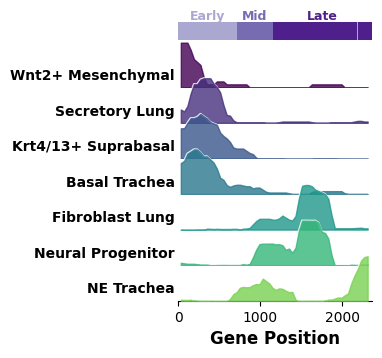

Saved: /scratch/chanj3/wangm10/HTAN/results/figures/HTAN_demo/figure6_cellmarker_ridge.png


In [48]:
# Figure 6: CellMarker_2024 gene-set ridge plot
# Fetch gene sets and filter to lung / trachea / brain terms
TISSUE_TERMS = ["lung", "trachea", "brain", "prefrontal cortex"]
full_library = gp.get_library(name="CellMarker_2024")
cellmarker_dict = {name: genes for name, genes in full_library.items() if any(t in name.lower() for t in TISSUE_TERMS)}
print(f"CellMarker sets matching tissue filter: {len(cellmarker_dict)}")

cm_enrichment_df = compute_running_enrichment(
    ordered_gene_names,
    cellmarker_dict,
    window_size=60,
    step_size=40,
)
print(f"CellMarker enrichment rows: {len(cm_enrichment_df)}")

# Preferred sets (same as basal_ridge_plot.py); fall back gracefully if absent
_cm_all_sets = cm_enrichment_df["gene_set"].unique().tolist()

_cm_sets_preferred = [
    "Wnt2+ Cell Lung Mouse",
    "Secretory Cell Lung Human",
    "Krt4/13+ Cell Trachea Mouse",
    "Basal Cell Trachea Mouse",
    "Fibroblast Lung Mouse",
    "Neural Progenitor Cell Embryonic Prefrontal Cortex Human",
    "Neuroendocrine Cell Trachea Mouse",
]
_cm_short_preferred = [
    "Wnt2+ Mesenchymal",
    "Secretory Lung",
    "Krt4/13+ Suprabasal",
    "Basal Trachea",
    "Fibroblast Lung",
    "Neural Progenitor",
    "NE Trachea",
]
cellmarker_sets_to_plot = [s for s in _cm_sets_preferred if s in _cm_all_sets]
cellmarker_short_names = [_cm_short_preferred[i] for i, s in enumerate(_cm_sets_preferred) if s in _cm_all_sets]
if not cellmarker_sets_to_plot:
    print("WARNING: none of the preferred sets found; falling back to top sets by peak score.")
    cellmarker_sets_to_plot = cm_enrichment_df.groupby("gene_set")["score"].max().nlargest(6).index.tolist()
    cellmarker_short_names = None

fig6 = plot_running_enrichment_ridge(
    cm_enrichment_df,
    gene_sets_to_plot=cellmarker_sets_to_plot,
    ordered_genes=ordered_gene_names,
    gene_curve=gene_curve_df,
    cutoff_points=cutoffs_norm,
    figsize=(2.5, 0.5 * len(cellmarker_sets_to_plot) + 1),
    short_names=cellmarker_short_names,
    save_path=str(FIG_DIR / "figure6_cellmarker_ridge.png"),
)
plt.show()
print(f"Saved: {FIG_DIR / 'figure6_cellmarker_ridge.png'}")

In [40]:
cellmarker_sets_to_plot

['Secretory Cell Lung Human',
 'Krt4/13+ Cell Trachea Mouse',
 'Fibroblast Lung Mouse',
 'Neural Progenitor Cell Embryonic Prefrontal Cortex Human',
 'Neuroendocrine Cell Trachea Mouse']

all_TNF-via-NFkB_signaling: 202 genes in set, 100 in ordered genes
all_IL6-JAK-STAT3_signaling: 87 genes in set, 22 in ordered genes
all_ros_response: 49 genes in set, 22 in ordered genes
all_mTORC1_signaling: 197 genes in set, 103 in ordered genes
all_hypoxia-response: 204 genes in set, 86 in ordered genes
all_MYC_targets: 83 genes in set, 41 in ordered genes
all_DNA-repair: 143 genes in set, 53 in ordered genes
Pathway enrichment rows: 399


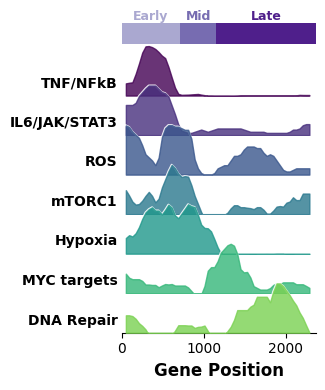

Saved: /scratch/chanj3/wangm10/HTAN/results/figures/HTAN_demo/figure7_pathway_ridge.png


In [95]:
# Figure 7: Pathway gene-set ridge plot loaded from external Spectra library
import pickle

gene_set_path = "/data1/chanj3/HTA.lung.NE_plasticity.120122/ref/Spectra.NE_NonNE.gene_sets.120524.p"
full_library = pickle.load(open(gene_set_path, "rb"))
gene_set_dict = full_library["global"]

gene_set_dict = remove_cell_cycle_genes(gene_set_dict)
gene_sets_to_plot = [
    "all_TNF-via-NFkB_signaling",
    "all_IL6-JAK-STAT3_signaling",
    "all_ros_response",
    "all_mTORC1_signaling",
    "all_hypoxia-response",
    "all_MYC_targets",
    "all_DNA-repair",
]

pathway_short_names = ["TNF/NFkB", "IL6/JAK/STAT3", "ROS", "mTORC1", "Hypoxia", "MYC targets", "DNA Repair"]

pathway_gene_sets = {k: gene_set_dict.get(k, []) for k in gene_sets_to_plot}
missing_sets = [k for k, v in pathway_gene_sets.items() if len(v) == 0]
if missing_sets:
    print("Missing requested sets in loaded library:", missing_sets)

# Report retained gene counts per requested pathway.
for set_name in gene_sets_to_plot:
    overlap_count = sum(g in ordered_gene_names for g in pathway_gene_sets.get(set_name, []))
    print(f"{set_name}: {len(pathway_gene_sets.get(set_name, []))} genes in set, {overlap_count} in ordered genes")

pathway_enrichment_df = compute_running_enrichment(
    ordered_gene_names,
    pathway_gene_sets,
    window_size=100,
    step_size=40,
)
print(f"Pathway enrichment rows: {len(pathway_enrichment_df)}")

fig7 = plot_running_enrichment_ridge(
    pathway_enrichment_df,
    gene_sets_to_plot=gene_sets_to_plot,
    ordered_genes=ordered_gene_names,
    gene_curve=gene_curve_df,
    cutoff_points=cutoffs_norm,
    figsize=(2.5, 5),
    short_names=pathway_short_names,
    save_path=str(FIG_DIR / "figure7_pathway_ridge.png"),
)
plt.show()
print(f"Saved: {FIG_DIR / 'figure7_pathway_ridge.png'}")

In [23]:
# Figure 12: Alternative transition-localization measures to highlight basal programs
import scipy.sparse as sp

if "cellmarker_dict" not in globals():
    raise RuntimeError("Run Cell 11 first to load CellMarker gene sets.")

# Keep the same epithelial/non-cycling scope so ranking is comparable to Figure 11.
if "include_terms" not in globals():
    include_terms = [
        "lung",
        "trachea",
        "airway",
        "bronch",
        "alveolar",
        "pneumocyte",
        "epithelial",
        "basal",
        "secretory",
        "club",
        "goblet",
        "ciliated",
        "tuft",
        "ionocyte",
        "krt4/13",
        "neuroendocrine",
    ]
if "exclude_terms" not in globals():
    exclude_terms = [
        "brain",
        "prefrontal",
        "fibroblast",
        "matrix fibroblast",
        "mesenchymal",
        "endothelial",
        "monocyte",
        "macrophage",
        "microgl",
        "neural",
        "neuron",
        "astrocyte",
        "oligodendro",
        "pericyte",
        "stromal",
        "immune",
        "lymph",
        "mast",
        "dendritic",
        "mural",
        "cycling",
        "prolifer",
        "cell cycle",
        "mitotic",
        "g2m",
        "s phase",
        "dna replication",
        "mki67",
        "t cell",
        "neutrophil",
    ]


def _is_epithelial_lung_trachea_set(name: str) -> bool:
    name_l = str(name).lower()
    has_include = any(term in name_l for term in include_terms)
    has_exclude = any(term in name_l for term in exclude_terms)
    return has_include and not has_exclude


n_bins = int(adata.uns[BARYCENTER_KEY]["expression"].shape[0])
transition_half_width = max(3, int(round(0.06 * n_bins)))
trans_bins = np.arange(
    max(0, int(boundary_1) - transition_half_width),
    min(n_bins - 1, int(boundary_1) + transition_half_width) + 1,
    dtype=int,
)

candidate_sets_alt = {
    name: genes
    for name, genes in cellmarker_dict.items()
    if _is_epithelial_lung_trachea_set(name) and (name != "Cancer Cell Lung Human")
}
gene_to_idx_alt = {g: i for i, g in enumerate(adata.var_names.astype(str))}
candidate_sets_alt = {name: [g for g in genes if g in gene_to_idx_alt] for name, genes in candidate_sets_alt.items()}
candidate_sets_alt = {name: genes for name, genes in candidate_sets_alt.items() if len(genes) >= 5}

enrichment_alt = temporal_kernel_pseudotime_enrichment(
    adata=adata,
    gene_sets=candidate_sets_alt,
    barycenter_key=BARYCENTER_KEY,
)

n_bins = int(adata.uns[BARYCENTER_KEY]["expression"].shape[0])
all_bins = np.arange(n_bins, dtype=int)
outside_bins = np.setdiff1d(all_bins, trans_bins)

pt_alt = adata.obs[ALIGNED_KEY].to_numpy(dtype=float)
bin_idx_alt = np.floor(np.clip(pt_alt, 0.0, 0.999999) * n_bins).astype(int)
patient_labels_alt = adata.obs[PATIENT_KEY].astype(str).to_numpy()
patient_ids_alt = np.unique(patient_labels_alt)
trans_bin_set = set(trans_bins.tolist())


def _safe_z(v):
    v = np.asarray(v, dtype=float)
    mu = np.nanmean(v)
    sd = np.nanstd(v)
    if (not np.isfinite(sd)) or sd < 1e-12:
        return np.zeros_like(v, dtype=float)
    return (v - mu) / sd


rows_alt = []
for set_name, sub in enrichment_alt.groupby("gene_set", observed=True):
    z = np.full(n_bins, np.nan, dtype=float)
    b = sub["bin"].to_numpy(dtype=int)
    z[b] = sub["zscore_within_set"].to_numpy(dtype=float)

    trans_vals = z[trans_bins]
    out_vals = z[outside_bins]
    trans_mean = float(np.nanmean(trans_vals))
    out_mean = float(np.nanmean(out_vals))
    transition_contrast = trans_mean - out_mean

    trans_peak = float(np.nanmax(trans_vals))
    out_peak = float(np.nanmax(out_vals))
    peak_advantage = trans_peak - out_peak

    z_filled = np.where(np.isfinite(z), z, -np.inf)
    peak_bin = int(np.argmax(z_filled))
    boundary_proximity = float(np.exp(-abs(peak_bin - int(boundary_1)) / max(1.0, len(trans_bins) / 2)))

    pos = np.clip(np.where(np.isfinite(z), z, 0.0), 0.0, None)
    pos_total = float(np.sum(pos))
    pos_transition = float(np.sum(pos[trans_bins]))
    transition_positive_mass_frac = (pos_transition / pos_total) if pos_total > 0 else 0.0

    # Patient-level consistency: peak bin falls inside transition neighborhood.
    idx = np.array([gene_to_idx_alt[g] for g in candidate_sets_alt[set_name]], dtype=int)
    support = []
    for pid in patient_ids_alt:
        pmask = patient_labels_alt == pid
        if pmask.sum() < 30:
            continue
        X = adata[pmask, idx].X
        if sp.issparse(X):
            cell_set_mean = np.asarray(X.mean(axis=1)).ravel()
        else:
            cell_set_mean = np.asarray(X, dtype=float).mean(axis=1)

        dfp = pd.DataFrame({"bin": bin_idx_alt[pmask], "signal": cell_set_mean})
        prof = dfp.groupby("bin", observed=True)["signal"].mean()
        zp = np.full(n_bins, np.nan, dtype=float)
        zp[prof.index.to_numpy(dtype=int)] = prof.to_numpy(dtype=float)
        valid = np.isfinite(zp)
        if valid.sum() < 8:
            continue
        mu = np.nanmean(zp)
        sd = np.nanstd(zp)
        if (not np.isfinite(sd)) or sd < 1e-12:
            continue
        zp = (zp - mu) / sd
        peak_p = int(np.argmax(np.where(np.isfinite(zp), zp, -np.inf)))
        support.append(float(peak_p in trans_bin_set))

    peak_transition_patient_frac = float(np.mean(support)) if support else np.nan

    rows_alt.append(
        {
            "gene_set": set_name,
            "display_name": set_name.replace(" Human", "").replace(" Mouse", ""),
            "is_basal": ("basal" in set_name.lower()),
            "transition_contrast": transition_contrast,
            "peak_advantage": peak_advantage,
            "boundary_proximity": boundary_proximity,
            "transition_positive_mass_frac": transition_positive_mass_frac,
            "peak_transition_patient_frac": peak_transition_patient_frac,
            "peak_bin": peak_bin,
            "n_genes_present": int(len(candidate_sets_alt[set_name])),
        }
    )

alt_metrics = pd.DataFrame(rows_alt)
if alt_metrics.empty:
    raise RuntimeError("No alternative metrics were computed.")

# Composite score emphasizes transition-localized sharpness and cross-patient consistency.
score_cols = [
    "transition_contrast",
    "peak_advantage",
    "boundary_proximity",
    "transition_positive_mass_frac",
    "peak_transition_patient_frac",
]
for c in score_cols:
    alt_metrics[f"{c}_z"] = _safe_z(alt_metrics[c].fillna(alt_metrics[c].median()))
alt_metrics["transition_localization_score"] = alt_metrics[[f"{c}_z" for c in score_cols]].mean(axis=1)
alt_metrics = alt_metrics.sort_values("transition_localization_score", ascending=False).reset_index(drop=True)
alt_metrics["rank_transition_localization"] = np.arange(1, len(alt_metrics) + 1)

short_name_map_alt = {
    "Secretory Cell Lung Human": "Secretory Lung",
    "Wnt2+ Cell Lung Mouse": "Wnt2+ Mesenchymal",
    "Krt4/13+ Cell Trachea Mouse": "Krt4/13+ Suprabasal",
    "Basal Cell Trachea Mouse": "Basal Trachea",
    "Basal Cell Lung Human": "Basal Lung",
    "Neuroendocrine Cell Trachea Mouse": "NE Trachea",
    "Goblet Cell Lung Human": "Goblet Lung",
    "Club Cell Lung Human": "Club Lung",
    "Ciliated Cell Trachea Mouse": "Ciliated Trachea",
    "Ionocyte Cell Lung Human": "Ionocyte Lung",
}
alt_metrics["display_short"] = alt_metrics["gene_set"].map(short_name_map_alt).fillna(alt_metrics["display_name"])

basal_alt = alt_metrics[alt_metrics["gene_set"] == "Basal Cell Trachea Mouse"].copy()
print("Basal Trachea rank under alternative transition-localization score:")
if basal_alt.empty:
    print("  Basal Cell Trachea Mouse not found in filtered candidate sets.")
else:
    r = basal_alt.iloc[0]
    print(
        f"  {r['display_short']}: rank {int(r['rank_transition_localization'])}/{len(alt_metrics)} | "
        f"TLS={r['transition_localization_score']:.2f}, "
        f"peak@bin={int(r['peak_bin'])}, "
        f"patient_peak_in_transition={r['peak_transition_patient_frac']:.2f}"
    )

Basal Trachea rank under alternative transition-localization score:
  Basal Trachea: rank 2/29 | TLS=1.00, peak@bin=0, patient_peak_in_transition=0.33


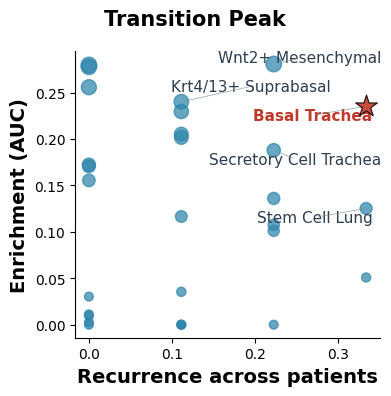

Saved: /scratch/chanj3/wangm10/HTAN/results/figures/HTAN_demo/figure12_transition_localization_alt_metrics.png
Annotated CellMarker sets (union of top 5 by AUC and top 5 by peak recurrence): ['Wnt2+ Cell Lung Mouse', 'Basal Cell Trachea Mouse', 'Secretory Cell Trachea Mouse', 'Krt4/13+ Cell Trachea Mouse', 'Stem Cell Lung Human']


In [85]:
fig12, ax12a = plt.subplots(1, 1, figsize=(4, 4))

is_basal_trachea = alt_metrics["gene_set"].eq("Basal Cell Trachea Mouse")
other12 = alt_metrics[~is_basal_trachea]
basal12 = alt_metrics[is_basal_trachea]

ax12a.scatter(
    other12["peak_transition_patient_frac"],
    other12["transition_positive_mass_frac"],
    c="#2E86AB",
    s=40 + 80 * np.clip(other12["transition_contrast"].to_numpy(dtype=float), 0, None),
    alpha=0.72,
)
if not basal12.empty:
    ax12a.scatter(
        basal12["peak_transition_patient_frac"],
        basal12["transition_positive_mass_frac"],
        c="#C0392B",
        edgecolor="black",
        linewidth=0.8,
        s=170 + 120 * np.clip(basal12["transition_contrast"].to_numpy(dtype=float), 0, None),
        marker="*",
        alpha=0.9,
        zorder=4,
    )
ax12a.set_xlabel("Recurrence across patients", fontsize=14, fontweight="bold")
ax12a.set_ylabel("Enrichment (AUC)", fontsize=14, fontweight="bold")
ax12a.spines["top"].set_visible(False)
ax12a.spines["right"].set_visible(False)

top_auc = alt_metrics.nlargest(5, "transition_positive_mass_frac")["gene_set"].tolist()
top_peak = alt_metrics.nlargest(5, "peak_transition_patient_frac")["gene_set"].tolist()

alt_metrics["rank_auc"] = alt_metrics["transition_positive_mass_frac"].rank(ascending=False, method="min")
alt_metrics["rank_peak"] = alt_metrics["peak_transition_patient_frac"].rank(ascending=False, method="min")
alt_metrics["rank_combined"] = alt_metrics["rank_auc"] + alt_metrics["rank_peak"]
n_top = 5
top_path = alt_metrics.sort_values(["rank_combined", "rank_auc", "rank_peak"]).head(n_top)["gene_set"].tolist()
label_gene_sets = []
for g in top_path + ["Basal Cell Trachea Mouse"]:
    if g in set(alt_metrics["gene_set"]) and g not in label_gene_sets:
        label_gene_sets.append(g)
label_df_alt = alt_metrics.set_index("gene_set").loc[label_gene_sets].reset_index()

texts = []
for _, r in label_df_alt.iterrows():
    is_basal = r["gene_set"] == "Basal Cell Trachea Mouse"
    texts.append(
        ax12a.text(
            r["peak_transition_patient_frac"],
            r["transition_positive_mass_frac"],
            r["display_short"],
            fontsize=11,
            color="#C0392B" if is_basal else "#2C3E50",
            fontweight="bold" if is_basal else None,
        )
    )
if texts:
    adjust_text(
        texts,
        ax=ax12a,
        expand_points=(1.08, 1.2),
        expand_text=(1.08, 1.18),
        force_points=0.35,
        force_text=0.62,
        arrowprops={"arrowstyle": "-", "color": "#7F8C8D", "lw": 0.55, "alpha": 0.75},
    )

topk = alt_metrics.head(12).copy()
bar_colors = ["#C0392B" if g == "Basal Cell Trachea Mouse" else "#6C8EBF" for g in topk["gene_set"]]
fig12.suptitle("Transition Peak", fontsize=15, fontweight="bold")

fig12.tight_layout()
f12 = FIG_DIR / "figure12_transition_localization_alt_metrics.png"
fig12.savefig(f12, dpi=220)
plt.show()
print(f"Saved: {f12}")
print("Annotated CellMarker sets (union of top 5 by AUC and top 5 by peak recurrence):", label_gene_sets)

In [65]:
# Figure 12B: Pathway transition-localization scatter (Spectra library)
import scipy.sparse as sp

if ("gene_set_dict" not in globals() or not isinstance(gene_set_dict, dict)) and (
    "pathway_gene_sets" not in globals() or not pathway_gene_sets
):
    raise RuntimeError(
        "Run the pathway-loading cell first so gene_set_dict (preferred) or pathway_gene_sets is available."
    )

# Use the full Spectra global pathway collection when available, not only the 5 ridge-plot pathways.
if "gene_set_dict" in globals() and isinstance(gene_set_dict, dict) and len(gene_set_dict) > 0:
    pathway_source_sets = gene_set_dict
    pathway_source_name = "full Spectra global pathway dictionary"
else:
    pathway_source_sets = pathway_gene_sets
    pathway_source_name = "pathway_gene_sets fallback"

if "trans_bins" in globals():
    trans_bins_path = np.asarray(trans_bins, dtype=int)
else:
    n_bins_tmp = int(adata.uns[BARYCENTER_KEY]["expression"].shape[0])
    transition_half_width = max(3, int(round(0.06 * n_bins_tmp)))
    trans_bins_path = np.arange(
        max(0, int(boundary_1) - transition_half_width),
        min(n_bins_tmp - 1, int(boundary_1) + transition_half_width) + 1,
        dtype=int,
    )

gene_to_idx_path = {g: i for i, g in enumerate(adata.var_names.astype(str))}
pathway_sets_alt = {name: [g for g in genes if g in gene_to_idx_path] for name, genes in pathway_source_sets.items()}
pathway_sets_alt = {name: genes for name, genes in pathway_sets_alt.items() if len(genes) >= 5}
if not pathway_sets_alt:
    raise RuntimeError("No pathway sets have >=5 genes present in adata.var_names.")

print(f"Pathway source: {pathway_source_name}")
print(f"Pathway sets retained for scatter: {len(pathway_sets_alt)} / {len(pathway_source_sets)}")

enrichment_path = temporal_kernel_pseudotime_enrichment(
    adata=adata,
    gene_sets=pathway_sets_alt,
    barycenter_key=BARYCENTER_KEY,
)

n_bins_path = int(adata.uns[BARYCENTER_KEY]["expression"].shape[0])
all_bins_path = np.arange(n_bins_path, dtype=int)
outside_bins_path = np.setdiff1d(all_bins_path, trans_bins_path)

pt_path = adata.obs[ALIGNED_KEY].to_numpy(dtype=float)
bin_idx_path = np.floor(np.clip(pt_path, 0.0, 0.999999) * n_bins_path).astype(int)
patient_labels_path = adata.obs[PATIENT_KEY].astype(str).to_numpy()
patient_ids_path = np.unique(patient_labels_path)
trans_bin_set_path = set(trans_bins_path.tolist())

rows_path = []
for set_name, sub in enrichment_path.groupby("gene_set", observed=True):
    z = np.full(n_bins_path, np.nan, dtype=float)
    b = sub["bin"].to_numpy(dtype=int)
    z[b] = sub["zscore_within_set"].to_numpy(dtype=float)

    trans_vals = z[trans_bins_path]
    out_vals = z[outside_bins_path]
    transition_contrast = float(np.nanmean(trans_vals) - np.nanmean(out_vals))

    pos = np.clip(np.where(np.isfinite(z), z, 0.0), 0.0, None)
    pos_total = float(np.sum(pos))
    pos_transition = float(np.sum(pos[trans_bins_path]))
    transition_positive_mass_frac = (pos_transition / pos_total) if pos_total > 0 else 0.0

    idx = np.array([gene_to_idx_path[g] for g in pathway_sets_alt[set_name]], dtype=int)
    support = []
    for pid in patient_ids_path:
        pmask = patient_labels_path == pid
        if pmask.sum() < 30:
            continue
        X = adata[pmask, idx].X
        if sp.issparse(X):
            cell_set_mean = np.asarray(X.mean(axis=1)).ravel()
        else:
            cell_set_mean = np.asarray(X, dtype=float).mean(axis=1)

        dfp = pd.DataFrame({"bin": bin_idx_path[pmask], "signal": cell_set_mean})
        prof = dfp.groupby("bin", observed=True)["signal"].mean()
        zp = np.full(n_bins_path, np.nan, dtype=float)
        zp[prof.index.to_numpy(dtype=int)] = prof.to_numpy(dtype=float)
        valid = np.isfinite(zp)
        if valid.sum() < 8:
            continue
        mu = np.nanmean(zp)
        sd = np.nanstd(zp)
        if (not np.isfinite(sd)) or sd < 1e-12:
            continue
        zp = (zp - mu) / sd
        peak_p = int(np.argmax(np.where(np.isfinite(zp), zp, -np.inf)))
        support.append(float(peak_p in trans_bin_set_path))

    peak_transition_patient_frac = float(np.mean(support)) if support else np.nan
    rows_path.append(
        {
            "gene_set": set_name,
            "transition_positive_mass_frac": transition_positive_mass_frac,
            "peak_transition_patient_frac": peak_transition_patient_frac,
            "transition_contrast": transition_contrast,
            "n_genes_present": int(len(pathway_sets_alt[set_name])),
        }
    )

pathway_alt_metrics = pd.DataFrame(rows_path)
if pathway_alt_metrics.empty:
    raise RuntimeError("No pathway transition-localization metrics were computed.")

if (
    "gene_sets_to_plot" in globals()
    and "pathway_short_names" in globals()
    and len(gene_sets_to_plot) == len(pathway_short_names)
):
    pathway_short_map = dict(zip(gene_sets_to_plot, pathway_short_names, strict=False))
else:
    pathway_short_map = {}
pathway_alt_metrics["display_short"] = (
    pathway_alt_metrics["gene_set"]
    .map(pathway_short_map)
    .fillna(pathway_alt_metrics["gene_set"].str.replace("all_", "", regex=False).str.replace("_", " ", regex=False))
)

Pathway source: full Spectra global pathway dictionary
Pathway sets retained for scatter: 65 / 147


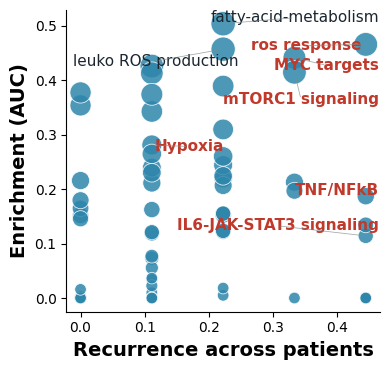

Saved: /scratch/chanj3/wangm10/HTAN/results/figures/HTAN_demo/figure12b_pathway_transition_localization_scatter.png
Annotated pathway sets (top 5 by combined AUC+peak ranking, plus TNF/NFkB, JAK/STAT, Hypoxia): ['all_ros_response', 'all_MYC_targets', 'all_fatty-acid-metabolism', 'all_mTORC1_signaling', 'leuko_ROS_production', 'all_TNF-via-NFkB_signaling', 'all_IL6-JAK-STAT3_signaling', 'all_hypoxia-response']


In [97]:
fig12b, ax12b_scatter = plt.subplots(figsize=(4, 3.8))
ax12b_scatter.scatter(
    pathway_alt_metrics["peak_transition_patient_frac"],
    pathway_alt_metrics["transition_positive_mass_frac"],
    c="#2E86AB",
    s=70 + 130 * np.clip(pathway_alt_metrics["transition_contrast"].to_numpy(dtype=float), 0, None),
    alpha=0.85,
    edgecolor="white",
    linewidth=0.6,
)
ax12b_scatter.set_xlabel("Recurrence across patients", fontsize=14, fontweight="bold")
ax12b_scatter.set_ylabel("Enrichment (AUC)", fontsize=14, fontweight="bold")
ax12b_scatter.spines["top"].set_visible(False)
ax12b_scatter.spines["right"].set_visible(False)

pathway_alt_metrics["rank_auc"] = pathway_alt_metrics["transition_positive_mass_frac"].rank(
    ascending=False, method="min"
)
pathway_alt_metrics["rank_peak"] = pathway_alt_metrics["peak_transition_patient_frac"].rank(
    ascending=False, method="min"
)
pathway_alt_metrics["rank_combined"] = pathway_alt_metrics["rank_auc"] + pathway_alt_metrics["rank_peak"]
top_combined_path = (
    pathway_alt_metrics.sort_values(["rank_combined", "rank_auc", "rank_peak"]).head(5)["gene_set"].tolist()
)
priority_gene_sets_path = [
    "all_TNF-via-NFkB_signaling",
    "all_IL6-JAK-STAT3_signaling",
    "all_MYC_targets",
    "all_mTORC1_signaling",
    "all_ros_response",
    "all_hypoxia-response",
]
label_gene_sets_path = []
for g in top_combined_path + priority_gene_sets_path:
    if g in set(pathway_alt_metrics["gene_set"]) and g not in label_gene_sets_path:
        label_gene_sets_path.append(g)
label_df_path = pathway_alt_metrics.set_index("gene_set").loc[label_gene_sets_path].reset_index()

texts_path = []
for _, r in label_df_path.iterrows():
    is_priority = r["gene_set"] in priority_gene_sets_path
    texts_path.append(
        ax12b_scatter.text(
            r["peak_transition_patient_frac"],
            r["transition_positive_mass_frac"],
            r["display_short"],
            fontsize=11,
            color="#C0392B" if is_priority else "#1B2631",
            fontweight="bold" if is_priority else None,
        )
    )
if texts_path:
    adjust_text(
        texts_path,
        ax=ax12b_scatter,
        expand_points=(1.08, 1.2),
        expand_text=(1.08, 1.18),
        force_points=0.35,
        force_text=0.62,
        arrowprops={"arrowstyle": "-", "color": "#7F8C8D", "lw": 0.55, "alpha": 0.75},
    )

fig12b.tight_layout()
f12b = FIG_DIR / "figure12b_pathway_transition_localization_scatter.png"
fig12b.savefig(f12b, dpi=220, bbox_inches="tight")
plt.show()
print(f"Saved: {f12b}")
print(
    "Annotated pathway sets (top 5 by combined AUC+peak ranking, plus TNF/NFkB, JAK/STAT, Hypoxia):",
    label_gene_sets_path,
)

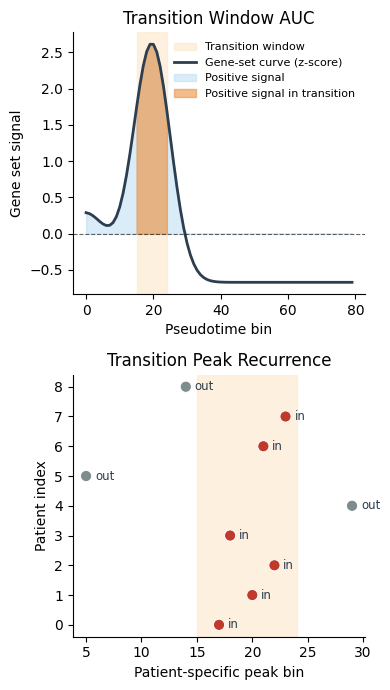

Saved: /scratch/chanj3/wangm10/HTAN/results/figures/HTAN_demo/metric_intuition_schematic.png


In [ ]:
# Schematic: intuitive geometry of patient peak fraction and positive-mass fraction
n_bins_s = 80
transition_idx = np.arange(20, 30)
x_s = np.arange(n_bins_s, dtype=float)
t_center = float(np.mean(transition_idx)) / max(1.0, (n_bins - 1)) * (n_bins_s - 1)
t_hw = max(4.0, len(transition_idx) / max(1.0, n_bins) * n_bins_s * 0.5)
t_start = int(max(0, np.floor(t_center - t_hw)))
t_end = int(min(n_bins_s - 1, np.ceil(t_center + t_hw)))
t_bins_s = np.arange(t_start, t_end + 1, dtype=int)

# Example cohort curve: one dominant transition peak plus weaker side activity.
curve = (
    1.2 * np.exp(-0.5 * ((x_s - t_center) / 5.5) ** 2)
    + 0.35 * np.exp(-0.5 * ((x_s - (t_center - 20)) / 7.0) ** 2)
    - 0.15
)
curve_z = (curve - np.mean(curve)) / (np.std(curve) + 1e-12)
curve_pos = np.clip(curve_z, 0.0, None)

mass_frac_demo = float(np.sum(curve_pos[t_bins_s]) / max(1e-12, np.sum(curve_pos)))

# Example per-patient peak bins (1 = peak in transition, 0 = outside).
patient_peak_bins_demo = np.array(
    [
        int(t_center - 2),
        int(t_center + 1),
        int(t_center + 3),
        int(t_center - 1),
        int(t_center + 10),
        int(t_center - 14),
        int(t_center + 2),
        int(t_center + 4),
        int(t_center - 5),
    ],
    dtype=int,
)
patient_in_transition_demo = np.array([int(b in set(t_bins_s.tolist())) for b in patient_peak_bins_demo], dtype=int)
patient_peak_frac_demo = float(np.mean(patient_in_transition_demo))

fig_int, (ax_i1, ax_i2) = plt.subplots(2, 1, figsize=(4, 7))

# Left panel: positive-mass fraction on curve.
ax_i1.axvspan(t_start, t_end, color="#FDEBD0", alpha=0.7, label="Transition window")
ax_i1.plot(x_s, curve_z, color="#2C3E50", linewidth=2.0, label="Gene-set curve (z-score)")
ax_i1.fill_between(x_s, 0, curve_pos, color="#AED6F1", alpha=0.45, label="Positive signal")
ax_i1.fill_between(
    x_s[t_bins_s], 0, curve_pos[t_bins_s], color="#EB984E", alpha=0.65, label="Positive signal in transition"
)
ax_i1.axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
ax_i1.set_title("Transition Window AUC")
ax_i1.set_xlabel("Pseudotime bin")
ax_i1.set_ylabel("Gene set signal")
ax_i1.legend(frameon=False, fontsize=8, loc="upper right")
ax_i1.spines["top"].set_visible(False)
ax_i1.spines["right"].set_visible(False)

# Right panel: patient peak-in-transition fraction.
y_pat = np.arange(len(patient_peak_bins_demo), dtype=int)
colors_pat = np.where(patient_in_transition_demo == 1, "#C0392B", "#7F8C8D")
ax_i2.axvspan(t_start, t_end, color="#FDEBD0", alpha=0.7)
ax_i2.scatter(patient_peak_bins_demo, y_pat, c=colors_pat, s=65, edgecolor="white", linewidth=0.7)
for yi, bi, flag in zip(y_pat, patient_peak_bins_demo, patient_in_transition_demo, strict=False):
    txt = "in" if flag == 1 else "out"
    ax_i2.text(bi + 0.8, yi, txt, va="center", fontsize=8.5, color="#2C3E50")
ax_i2.set_title("Transition Peak Recurrence")
ax_i2.set_xlabel("Patient-specific peak bin")
ax_i2.set_ylabel("Patient index")
ax_i2.spines["top"].set_visible(False)
ax_i2.spines["right"].set_visible(False)

fig_int.tight_layout()
f_int = FIG_DIR / "metric_intuition_schematic.png"
fig_int.savefig(f_int, dpi=220, bbox_inches="tight")
plt.show()
print(f"Saved: {f_int}")